In [1]:
import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score, f1_score, ConfusionMatrixDisplay
import random
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# Inicialitzation

In [2]:
# --- General configuration ---
'''
A seed (SEED) is set to guarantee reproducibility of results.
The GPU is automatically selected if available, otherwise the CPU.
'''
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# --- Data loading ---
''' 
A function is defined to load pickle files.
Training and test data are loaded.
The data is expected in DataFrame format with a 'sensor_data' column 
(each row is a sequence of measurements) and a list of labels.
'''

def load_pickle(fname):
    with open(fname, "rb") as f:
        return pickle.load(f)

# Load all datasets
X_train = load_pickle("../data/data_2.0/X_train.pickle")
y_train = load_pickle("../data/data_2.0/y_train.pickle")
X_test  = load_pickle("../data/data_2.0/X_test.pickle")
y_test  = load_pickle("../data/data_2.0/y_test.pickle")

X_ext_train = load_pickle("../data/data_2.0/X_ext_train.pickle")
X_ext_test  = load_pickle("../data/data_2.0/X_ext_test.pickle")

In [4]:
X_train.head(3)

,sensor_data,velocity,mass,deceleration_average
ID,,,,
0,"[[-0.28072790806722514, 0.48853950707154553, -...",0.671647,-0.775847,0.159472
1,"[[-0.2718687183472922, 0.4784524841297032, -1....",0.671647,-0.775847,0.169783
2,"[[-0.5490941730977201, 0.7122423836105083, -0....",-0.000498,-0.775847,-0.232540


In [5]:
# --- Data cleaning: handle missing values ---
# Check if there are NaN values in the 'mass' column of X_test
if 'mass' in X_test.columns:
    print(X_test['mass'].isnull().sum())
    print(X_test['mass'].isnull().any())

1001
True


In [6]:
# Replace NaN values in the 'mass' column of X_test with 0
if 'mass' in X_test.columns:
    X_test['mass'] = X_test['mass'].fillna(0)

In [7]:
if 'mass' in X_test.columns:
    print(X_test['mass'].isnull().sum())
    print(X_test['mass'].isnull().any())

0
False


In [8]:
# Repeat for X_ext_test
if 'mass' in X_ext_test.columns:
    print(X_ext_test['mass'].isnull().sum())
    print(X_ext_test['mass'].isnull().any())

1001
True


In [9]:
# Replace NaN values in the 'mass' column of X_ext_test with 0
if 'mass' in X_ext_test.columns:
    X_ext_test['mass'] = X_ext_test['mass'].fillna(0)

In [10]:
if 'mass' in X_ext_test.columns:
    print(X_ext_test['mass'].isnull().sum())
    print(X_ext_test['mass'].isnull().any())

0
False


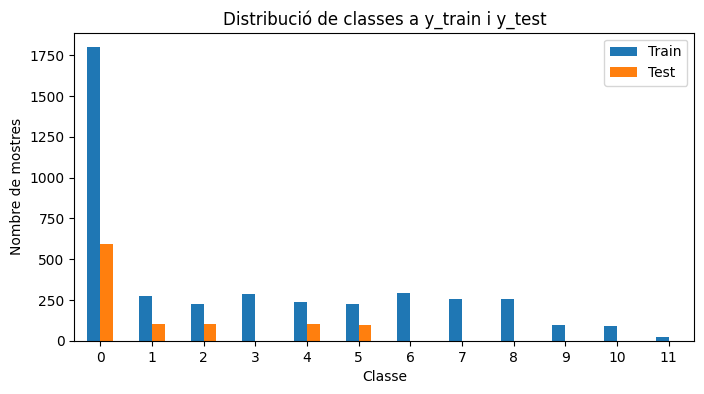

In [11]:
# --- Visualize class distribution ---
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

df_counts = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).fillna(0).astype(int)

df_counts.plot(kind='bar', figsize=(8,4))
plt.xlabel('Classe')
plt.ylabel('Nombre de mostres')
plt.title('Distribució de classes a y_train i y_test')
plt.xticks(rotation=0)
plt.show()

In [12]:
X_ext_train.head(3)

,sensor_data,velocity,mass,deceleration_average,pers_image,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9
ID,,,,,,,,,,,,,,,
0,"[[-0.28072790806722514, 0.48853950707154553, -...",0.671647,-0.775847,0.159472,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.125385,-1.245574,1.067122,-0.871628,-1.044507,-1.386314,-0.072213,1.186151,-0.409863,0.267901
1,"[[-0.2718687183472922, 0.4784524841297032, -1....",0.671647,-0.775847,0.169783,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.386891,-2.581249,1.607560,-0.955609,-0.127401,-1.316814,-0.135856,1.165788,-0.345084,-0.159023
2,"[[-0.5490941730977201, 0.7122423836105083, -0....",-0.000498,-0.775847,-0.232540,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.361358,-1.164561,-0.493627,-1.585966,-0.108352,-0.726434,0.777122,0.274905,0.911691,0.303875


In [13]:
y_train

ID
0       3
1       3
2       3
3       3
4       3
       ..
4048    4
4049    4
4050    4
4051    4
4052    4
Name: label, Length: 4053, dtype: int64

In [14]:
# --- Check unique labels in train and test sets ---
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Unique labels in y_test: [0 1 2 4 5]


# Original data

In [15]:
# --- Prepare tensors and DataLoaders ---
'''
prepare_data:
Converts the data to PyTorch tensors.
Performs a random split (with fixed seed) to separate training and validation.
Returns two DataLoaders: one for training and one for validation.

prepare_test:
Prepares the DataLoader for the test set.
'''

def prepare_data(X_df, y, batch_size=64, split_val=0.2):
    # Convert DataFrame column 'sensor_data' to tensor (N, 6, seq_len)
    X = np.stack(X_df['sensor_data'].tolist()).astype(np.float32)  
    X = torch.from_numpy(X).permute(0,2,1)  
    y = torch.tensor(np.array(y), dtype=torch.long)
    ds = TensorDataset(X, y)
    # Split into training and validation sets
    n_val = int(len(ds) * split_val)
    n_train = len(ds) - n_val
    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

def prepare_test(X_df, y, batch_size=64):
    # Prepare test DataLoader
    X = np.stack(X_df['sensor_data'].tolist()).astype(np.float32)
    X = torch.from_numpy(X).permute(0,2,1)
    y = torch.tensor(np.array(y), dtype=torch.long)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

## Without Dropout and without class weighting

Function: train_model

In [16]:
# --- Define the FCN1D model ---
'''
A fully convolutional network (FCN) for time series:
3 1D convolutional layers with BatchNorm and ReLU.
Adaptive pooling to reduce the sequence to a vector.
Final linear layer for binary (or multiclass if you change num_classes) classification.
'''

class FCN1D(nn.Module):
    def __init__(self, input_channels=6, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

In [17]:
# --- Training and validation ---
'''
Trains the model for several epochs.
After each epoch, evaluates the validation accuracy.
Saves the model with the best validation accuracy.
Returns the best model found.
'''

def train_model(train_loader, val_loader, num_classes=2, epochs=5, lr=1e-3):
    model = FCN1D(input_channels=6, num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0
    best_model = model.state_dict()  
    for epoch in range(1, epochs+1):
        model.train()

        # Training loop
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            
        # Validation after each epoch
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()
        print(f"Epoch {epoch:2d} | Val Accuracy: {val_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return model

In [18]:
# --- Test ---
'''
Evaluates the model on the test set.
Calculates and shows the accuracy.
'''

def test_model(model, test_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())
    acc = accuracy_score(all_targets, all_preds)
    print(f"Test Accuracy: {acc*100:.2f}%")
    return acc


--- Training with lr=0.001, batch_size=32 ---
Epoch  1 | Val Accuracy: 80.74%
Epoch  2 | Val Accuracy: 95.56%
Epoch  3 | Val Accuracy: 98.02%
Epoch  4 | Val Accuracy: 97.53%
Epoch  5 | Val Accuracy: 97.78%
Test Accuracy: 29.07%

--- Training with lr=0.001, batch_size=64 ---
Epoch  1 | Val Accuracy: 71.73%
Epoch  2 | Val Accuracy: 90.37%
Epoch  3 | Val Accuracy: 94.94%
Epoch  4 | Val Accuracy: 97.65%
Epoch  5 | Val Accuracy: 98.15%
Test Accuracy: 30.77%

--- Training with lr=0.0005, batch_size=32 ---
Epoch  1 | Val Accuracy: 76.30%
Epoch  2 | Val Accuracy: 89.63%
Epoch  3 | Val Accuracy: 94.32%
Epoch  4 | Val Accuracy: 96.54%
Epoch  5 | Val Accuracy: 97.78%
Test Accuracy: 43.26%

--- Training with lr=0.0005, batch_size=64 ---
Epoch  1 | Val Accuracy: 70.12%
Epoch  2 | Val Accuracy: 78.77%
Epoch  3 | Val Accuracy: 87.28%
Epoch  4 | Val Accuracy: 92.84%
Epoch  5 | Val Accuracy: 96.17%
Test Accuracy: 44.46%

Summary of hyperparameter combinations:
{'lr': 0.001, 'batch_size': 32, 'test_acc

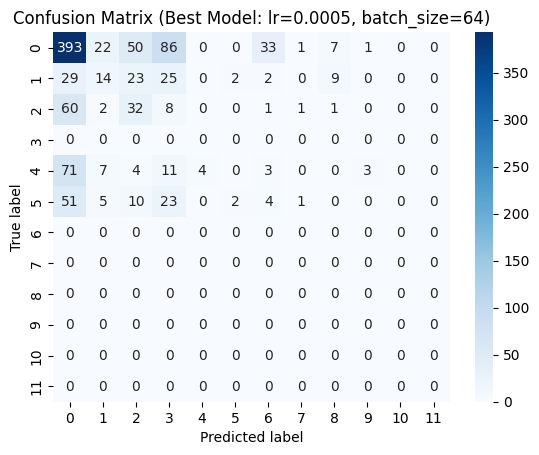

Accuracy: 0.44455544455544455
Balanced accuracy: 0.2323554892010089
Macro F1: 0.12389404266826798
Weighted F1: 0.44938910755891615

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.66      0.66       593
           1       0.28      0.13      0.18       104
           2       0.27      0.30      0.29       105
           4       1.00      0.04      0.07       103
           5       0.50      0.02      0.04        96

   micro avg       0.57      0.44      0.50      1001
   macro avg       0.54      0.23      0.25      1001
weighted avg       0.59      0.44      0.45      1001



C:\Users\Sarad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [19]:
# --- Hyperparameter search for FCN1D ---
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
epochs = 5
results = []

num_classes = int(np.max(y_train)) + 1

best_acc = 0
best_model = None
best_params = {}

# Grid search over learning rates and batch sizes
for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"\n--- Training with lr={lr}, batch_size={batch_size} ---")
        train_loader, val_loader = prepare_data(X_train, y_train, batch_size=batch_size)
        test_loader = prepare_test(X_test, y_test, batch_size=batch_size)
        model = train_model(train_loader, val_loader, num_classes=num_classes, epochs=epochs, lr=lr)
        acc = test_model(model, test_loader)
        results.append({'lr': lr, 'batch_size': batch_size, 'test_acc': acc})

        # Save best model
        if acc > best_acc:
            best_acc = acc
            best_model = copy.deepcopy(model)
            best_params = {'lr': lr, 'batch_size': batch_size}

print("\nSummary of hyperparameter combinations:")
for r in results:
    print(r)

print(f"\nBest model: lr={best_params['lr']}, batch_size={best_params['batch_size']}, test_acc={best_acc:.2f}")
best_acc_no_dropout = best_acc
best_params_no_dropout = best_params.copy()

# --- Evaluate best model on test set and show confusion matrix ---
y_true = []
y_pred = []
best_model.eval()
with torch.no_grad():
    for Xb, yb in prepare_test(X_test, y_test, batch_size=best_params['batch_size']):
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = best_model(Xb)
        preds = outputs.argmax(dim=1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

all_labels = np.arange(0, 12)  
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(8*0.8,6*0.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix (Best Model: lr={best_params['lr']}, batch_size={best_params['batch_size']})")
plt.show()

labels_test = np.unique(y_true)  

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_true, y_pred, average='weighted'))
print("\nClassification report:\n", classification_report(y_true, y_pred, labels=labels_test, zero_division=0))


## With Dropout, without class weighting

Function: train_model_dropout

In [20]:
# --- Define the FCN1D model with Dropout ---
'''
Version of FCN1D with Dropout to avoid overfitting.
The dropout_p parameter controls the proportion of deactivated neurons.
'''

class FCN1D_Dropout(nn.Module):
    def __init__(self, input_channels=6, num_classes=2, dropout_p=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Forward pass through convolutional layers and dropout
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

In [21]:
# --- Training and validation adapted for Dropout ---
def train_model_dropout(train_loader, val_loader, num_classes=2, epochs=5, lr=1e-3, dropout_p=0.3):
    # Initialize model with dropout
    model = FCN1D_Dropout(input_channels=6, num_classes=num_classes, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0
    best_model = model.state_dict()
    for epoch in range(1, epochs+1):
        model.train()

        # Training loop over batches
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            
        # Validation after each epoch
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()
        print(f"Epoch {epoch:2d} | Val Accuracy: {val_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return model


--- Training with lr=0.001, batch_size=32, dropout_p=0.2 ---
Epoch  1 | Val Accuracy: 79.38%
Epoch  2 | Val Accuracy: 93.33%
Epoch  3 | Val Accuracy: 96.67%
Epoch  4 | Val Accuracy: 96.67%
Epoch  5 | Val Accuracy: 98.15%
Test Accuracy: 32.47%

--- Training with lr=0.001, batch_size=32, dropout_p=0.3 ---
Epoch  1 | Val Accuracy: 85.80%
Epoch  2 | Val Accuracy: 92.59%
Epoch  3 | Val Accuracy: 97.04%
Epoch  4 | Val Accuracy: 97.53%
Epoch  5 | Val Accuracy: 98.27%
Test Accuracy: 39.56%

--- Training with lr=0.001, batch_size=32, dropout_p=0.5 ---
Epoch  1 | Val Accuracy: 81.73%
Epoch  2 | Val Accuracy: 91.23%
Epoch  3 | Val Accuracy: 96.05%
Epoch  4 | Val Accuracy: 97.65%
Epoch  5 | Val Accuracy: 98.15%
Test Accuracy: 41.86%

--- Training with lr=0.001, batch_size=64, dropout_p=0.2 ---
Epoch  1 | Val Accuracy: 67.53%
Epoch  2 | Val Accuracy: 88.77%
Epoch  3 | Val Accuracy: 95.56%
Epoch  4 | Val Accuracy: 97.53%
Epoch  5 | Val Accuracy: 98.15%
Test Accuracy: 42.16%

--- Training with lr=0.

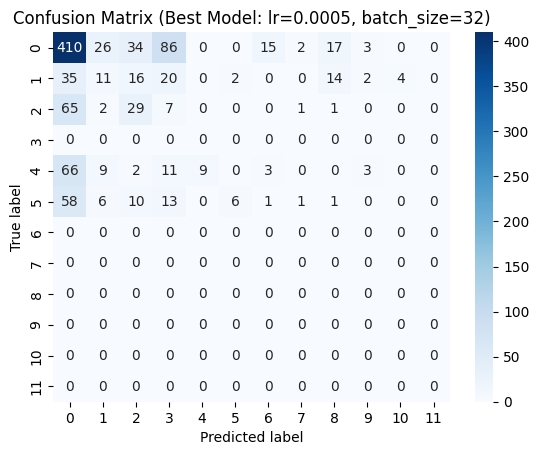

Accuracy: 0.4645354645354645
Balanced accuracy: 0.24464760209365552
Macro F1: 0.12541403939015103
Weighted F1: 0.46901384039516325

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.69      0.67       593
           1       0.20      0.11      0.14       104
           2       0.32      0.28      0.30       105
           4       1.00      0.09      0.16       103
           5       0.75      0.06      0.12        96

   micro avg       0.58      0.46      0.52      1001
   macro avg       0.58      0.24      0.28      1001
weighted avg       0.61      0.46      0.47      1001



C:\Users\Sarad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [22]:
# --- Hyperparameter search for FCN1D with Dropout ---
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
dropout_ps = [0.2, 0.3, 0.5]  
epochs = 5
results = []

num_classes = int(np.max(y_train)) + 1

best_acc = 0
best_model = None
best_params = {}

# Grid search over learning rates, batch sizes, and dropout probabilities
for lr in learning_rates:
    for batch_size in batch_sizes:
        for dropout_p in dropout_ps:
            print(f"\n--- Training with lr={lr}, batch_size={batch_size}, dropout_p={dropout_p} ---")
            train_loader, val_loader = prepare_data(X_train, y_train, batch_size=batch_size)
            test_loader = prepare_test(X_test, y_test, batch_size=batch_size)
            # Train model with current hyperparameters
            model = train_model_dropout(train_loader, val_loader, num_classes=num_classes, epochs=epochs, lr=lr, dropout_p=dropout_p)
            # Evaluate on test set
            acc = test_model(model, test_loader)
            results.append({'lr': lr, 'batch_size': batch_size, 'dropout_p': dropout_p, 'test_acc': acc})

            # Save best model found so far
            if acc > best_acc:
                best_acc = acc
                best_model = copy.deepcopy(model)
                best_params = {'lr': lr, 'batch_size': batch_size, 'dropout_p': dropout_p}

print("\nSummary of hyperparameter combinations:")
for r in results:
    print(r)

print(f"\nBest model: lr={best_params['lr']}, batch_size={best_params['batch_size']}, dropout_p={best_params['dropout_p']}, test_acc={best_acc:.2f}")
best_acc_dropout = best_acc
best_params_dropout = best_params.copy()

# --- Evaluate best model on test set and show confusion matrix ---
y_true = []
y_pred = []
best_model.eval()
with torch.no_grad():
    for Xb, yb in prepare_test(X_test, y_test, batch_size=best_params['batch_size']):
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = best_model(Xb)
        preds = outputs.argmax(dim=1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
all_labels = np.arange(0, 12)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(8*0.8,6*0.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix (Best Model: lr={best_params['lr']}, batch_size={best_params['batch_size']})")
plt.show()

labels_test = np.unique(y_true)  

# Print evaluation metrics for the best model
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_true, y_pred, average='weighted'))
print("\nClassification report:\n", classification_report(y_true, y_pred, labels=labels_test, zero_division=0))


## Without Dropout, with weighted CrossEntropyLoss

Function: train_model_weighted

In [23]:
# --- Training and validation with class weighting ---
def train_model_weighted(train_loader, val_loader, num_classes=2, epochs=5, lr=1e-3, class_weights=None):
    # Initialize model (without dropout) and optimizer
    model = FCN1D(input_channels=6, num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Use weighted CrossEntropyLoss to handle class imbalance
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    best_val_acc = 0
    best_model = model.state_dict()
    for epoch in range(1, epochs+1):
        model.train()
        
        # Training loop over batches
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            
        # Validation after each epoch
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()
        print(f"Epoch {epoch:2d} | Val Accuracy: {val_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return model


--- Training with lr=0.001, batch_size=32 (weighted loss) ---
Epoch  1 | Val Accuracy: 78.52%
Epoch  2 | Val Accuracy: 91.23%
Epoch  3 | Val Accuracy: 95.68%
Epoch  4 | Val Accuracy: 97.90%
Epoch  5 | Val Accuracy: 98.64%
Test Accuracy: 32.37%

--- Training with lr=0.001, batch_size=64 (weighted loss) ---
Epoch  1 | Val Accuracy: 75.06%
Epoch  2 | Val Accuracy: 84.81%
Epoch  3 | Val Accuracy: 90.99%
Epoch  4 | Val Accuracy: 92.47%
Epoch  5 | Val Accuracy: 95.43%
Test Accuracy: 21.48%

--- Training with lr=0.0005, batch_size=32 (weighted loss) ---
Epoch  1 | Val Accuracy: 69.14%
Epoch  2 | Val Accuracy: 81.73%
Epoch  3 | Val Accuracy: 88.52%
Epoch  4 | Val Accuracy: 91.98%
Epoch  5 | Val Accuracy: 93.58%
Test Accuracy: 14.99%

--- Training with lr=0.0005, batch_size=64 (weighted loss) ---
Epoch  1 | Val Accuracy: 70.25%
Epoch  2 | Val Accuracy: 78.40%
Epoch  3 | Val Accuracy: 84.57%
Epoch  4 | Val Accuracy: 89.14%
Epoch  5 | Val Accuracy: 92.10%
Test Accuracy: 17.48%

Summary of hyperp

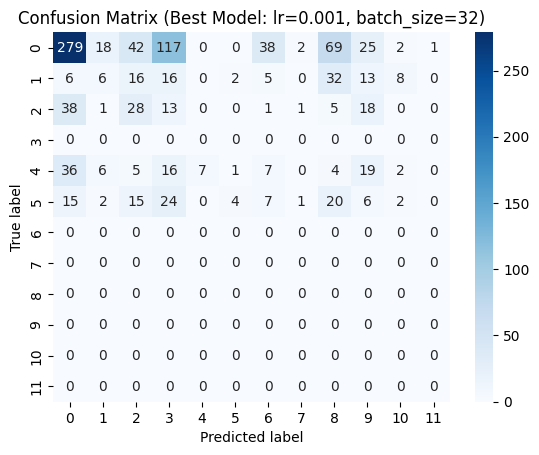

Accuracy: 0.32367632367632365
Balanced accuracy: 0.18089516897200386
Macro F1: 0.09458159281965466
Weighted F1: 0.3993290029244826

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.47      0.58       593
           1       0.18      0.06      0.09       104
           2       0.26      0.27      0.27       105
           4       1.00      0.07      0.13       103
           5       0.57      0.04      0.08        96

   micro avg       0.61      0.32      0.42      1001
   macro avg       0.55      0.18      0.23      1001
weighted avg       0.65      0.32      0.40      1001



C:\Users\Sarad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [24]:
# --- Hyperparameter search for FCN1D with weighted CrossEntropy ---
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
epochs = 5
results = []

num_classes = int(np.max(y_train)) + 1

# Compute class weights to handle class imbalance
class_counts = np.bincount(y_train)
weights = 1. / class_counts
weights = torch.tensor(weights, dtype=torch.float32).to(device)

best_acc = 0
best_model = None
best_params = {}

# Grid search over learning rates and batch sizes
for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"\n--- Training with lr={lr}, batch_size={batch_size} (weighted loss) ---")
        train_loader, val_loader = prepare_data(X_train, y_train, batch_size=batch_size)
        test_loader = prepare_test(X_test, y_test, batch_size=batch_size)
        # Train model with current hyperparameters and class weights
        model = train_model_weighted(train_loader, val_loader, num_classes=num_classes, epochs=epochs, lr=lr, class_weights=weights)
        # Evaluate on test set
        acc = test_model(model, test_loader)
        results.append({'lr': lr, 'batch_size': batch_size, 'test_acc': acc})

        # Save best model found so far
        if acc > best_acc:
            best_acc = acc
            best_model = copy.deepcopy(model)
            best_params = {'lr': lr, 'batch_size': batch_size}

print("\nSummary of hyperparameter combinations:")
for r in results:
    print(r)

print(f"\nBest model: lr={best_params['lr']}, batch_size={best_params['batch_size']}, test_acc={best_acc:.2f}")
best_acc_weighted = best_acc
best_params_weighted = best_params.copy()

# --- Evaluate best model on test set and show confusion matrix ---
y_true = []
y_pred = []
best_model.eval()
with torch.no_grad():
    for Xb, yb in prepare_test(X_test, y_test, batch_size=best_params['batch_size']):
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = best_model(Xb)
        preds = outputs.argmax(dim=1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
all_labels = np.arange(0, num_classes)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(8*0.8,6*0.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix (Best Model: lr={best_params['lr']}, batch_size={best_params['batch_size']})")
plt.show()

labels_test = np.unique(y_true)  

# Print evaluation metrics for the best model
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_true, y_pred, average='weighted'))
print("\nClassification report:\n", classification_report(y_true, y_pred, labels=labels_test, zero_division=0))


## With Dropout and weighted CrossEntropyLoss

Function: train_model_dropout_weighted

In [25]:
# --- Training and validation with dropout and class weighting ---
def train_model_dropout_weighted(train_loader, val_loader, num_classes=2, epochs=5, lr=1e-3, dropout_p=0.3, class_weights=None):
    # Initialize model with dropout and class weights
    model = FCN1D_Dropout(input_channels=6, num_classes=num_classes, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Use weighted CrossEntropyLoss to handle class imbalance
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    best_val_acc = 0
    best_model = model.state_dict()
    for epoch in range(1, epochs+1):
        model.train()
        # Training loop over batches
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # Validation after each epoch
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()
        print(f"Epoch {epoch:2d} | Val Accuracy: {val_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return model


--- Training with lr=0.001, batch_size=32, dropout_p=0.2 (weighted loss) ---
Epoch  1 | Val Accuracy: 83.83%
Epoch  2 | Val Accuracy: 92.59%
Epoch  3 | Val Accuracy: 96.42%
Epoch  4 | Val Accuracy: 97.65%
Epoch  5 | Val Accuracy: 97.65%
Test Accuracy: 29.57%

--- Training with lr=0.001, batch_size=32, dropout_p=0.3 (weighted loss) ---
Epoch  1 | Val Accuracy: 77.41%
Epoch  2 | Val Accuracy: 90.49%
Epoch  3 | Val Accuracy: 94.57%
Epoch  4 | Val Accuracy: 97.41%
Epoch  5 | Val Accuracy: 96.54%
Test Accuracy: 19.68%

--- Training with lr=0.001, batch_size=32, dropout_p=0.5 (weighted loss) ---
Epoch  1 | Val Accuracy: 69.14%
Epoch  2 | Val Accuracy: 84.81%
Epoch  3 | Val Accuracy: 92.47%
Epoch  4 | Val Accuracy: 95.43%
Epoch  5 | Val Accuracy: 96.17%
Test Accuracy: 21.58%

--- Training with lr=0.001, batch_size=64, dropout_p=0.2 (weighted loss) ---
Epoch  1 | Val Accuracy: 74.07%
Epoch  2 | Val Accuracy: 79.51%
Epoch  3 | Val Accuracy: 87.90%
Epoch  4 | Val Accuracy: 90.00%
Epoch  5 | Val

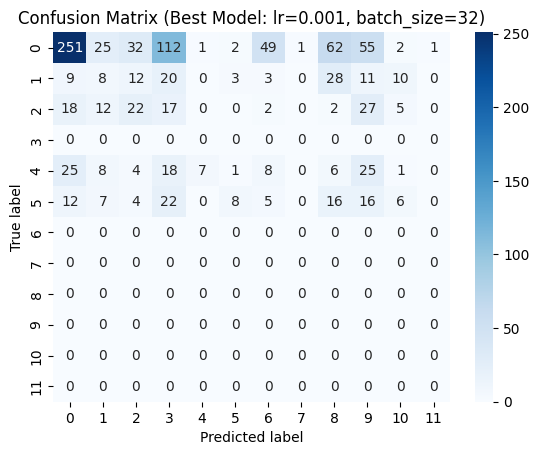

Accuracy: 0.2957042957042957
Balanced accuracy: 0.17220257713438678
Macro F1: 0.0973179282649748
Weighted F1: 0.39036867363147765

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.42      0.55       593
           1       0.13      0.08      0.10       104
           2       0.30      0.21      0.25       105
           4       0.88      0.07      0.13       103
           5       0.57      0.08      0.15        96

   micro avg       0.63      0.30      0.40      1001
   macro avg       0.53      0.17      0.23      1001
weighted avg       0.66      0.30      0.39      1001



C:\Users\Sarad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [26]:
# --- Hyperparameter search for FCN1D with Dropout + weighted CrossEntropy ---
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
dropout_ps = [0.2, 0.3, 0.5]
epochs = 5
results = []

num_classes = int(np.max(y_train)) + 1

# Compute class weights to handle class imbalance
class_counts = np.bincount(y_train)
weights = 1. / class_counts
weights = torch.tensor(weights, dtype=torch.float32).to(device)

best_acc = 0
best_model = None
best_params = {}

# Grid search over learning rates, batch sizes, and dropout probabilities
for lr in learning_rates:
    for batch_size in batch_sizes:
        for dropout_p in dropout_ps:
            print(f"\n--- Training with lr={lr}, batch_size={batch_size}, dropout_p={dropout_p} (weighted loss) ---")
            train_loader, val_loader = prepare_data(X_train, y_train, batch_size=batch_size)
            test_loader = prepare_test(X_test, y_test, batch_size=batch_size)
            # Train model with current hyperparameters and class weights
            model = train_model_dropout_weighted(
                train_loader, val_loader,
                num_classes=num_classes,
                epochs=epochs,
                lr=lr,
                dropout_p=dropout_p,
                class_weights=weights
            )

            # Evaluate on test set
            acc = test_model(model, test_loader)
            results.append({'lr': lr, 'batch_size': batch_size, 'dropout_p': dropout_p, 'test_acc': acc})

            # Save best model found so far
            if acc > best_acc:
                best_acc = acc
                best_model = copy.deepcopy(model)
                best_params = {'lr': lr, 'batch_size': batch_size, 'dropout_p': dropout_p}

print("\nSummary of hyperparameter combinations:")
for r in results:
    print(r)

print(f"\nBest model: lr={best_params['lr']}, batch_size={best_params['batch_size']}, dropout_p={best_params['dropout_p']}, test_acc={best_acc:.2f}")
best_acc_dropout_weighted = best_acc
best_params_dropout_weighted = best_params.copy()

# --- Evaluate best model on test set and show confusion matrix ---
y_true = []
y_pred = []
best_model.eval()
with torch.no_grad():
    for Xb, yb in prepare_test(X_test, y_test, batch_size=best_params['batch_size']):
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = best_model(Xb)
        preds = outputs.argmax(dim=1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
all_labels = np.arange(0, num_classes)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(8*0.8,6*0.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix (Best Model: lr={best_params['lr']}, batch_size={best_params['batch_size']})")
plt.show()

labels_test = np.unique(y_true)  

# Print evaluation metrics for the best model
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_true, y_pred, average='weighted'))
print("\nClassification report:\n", classification_report(y_true, y_pred, labels=labels_test, zero_division=0))


## Summary

In [27]:
# --- Collect and display the best results for each model configuration ---
summary = [
    {
        "Model": "FCN1D (no Dropout, no weights)",
        "Dropout": "No",
        "Class Weights": "No",
        "Best Accuracy": f"{best_acc_no_dropout*100:.2f}%",
        "Learning Rate": best_params_no_dropout['lr'],
        "Batch Size": best_params_no_dropout['batch_size'],
        "Dropout p": "-"
    },
    {
        "Model": "FCN1D (Dropout, no weights)",
        "Dropout": "Yes",
        "Class Weights": "No",
        "Best Accuracy": f"{best_acc_dropout*100:.2f}%",
        "Learning Rate": best_params_dropout['lr'],
        "Batch Size": best_params_dropout['batch_size'],
        "Dropout p": best_params_dropout['dropout_p']
    },
    {
        "Model": "FCN1D (no Dropout, with weights)",
        "Dropout": "No",
        "Class Weights": "Yes",
        "Best Accuracy": f"{best_acc_weighted*100:.2f}%",
        "Learning Rate": best_params_weighted['lr'],
        "Batch Size": best_params_weighted['batch_size'],
        "Dropout p": "-"
    },
    {
        "Model": "FCN1D (Dropout, with weights)",
        "Dropout": "Yes",
        "Class Weights": "Yes",
        "Best Accuracy": f"{best_acc_dropout_weighted*100:.2f}%",
        "Learning Rate": best_params_dropout_weighted['lr'],
        "Batch Size": best_params_dropout_weighted['batch_size'],
        "Dropout p": best_params_dropout_weighted['dropout_p']
    }
]

df_summary = pd.DataFrame(summary)
print(df_summary.to_markdown(index=False))

| Model                            | Dropout   | Class Weights   | Best Accuracy   |   Learning Rate |   Batch Size | Dropout p   |
|:---------------------------------|:----------|:----------------|:----------------|----------------:|-------------:|:------------|
| FCN1D (no Dropout, no weights)   | No        | No              | 44.46%          |          0.0005 |           64 | -           |
| FCN1D (Dropout, no weights)      | Yes       | No              | 46.45%          |          0.0005 |           32 | 0.3         |
| FCN1D (no Dropout, with weights) | No        | Yes             | 32.37%          |          0.001  |           32 | -           |
| FCN1D (Dropout, with weights)    | Yes       | Yes             | 29.57%          |          0.001  |           32 | 0.2         |


# Extended data

In [28]:
# --- Prepare tensors and DataLoaders for all features ---
def prepare_data_all_features(X_df, y, batch_size=64, split_val=0.2):
    # Get all feature columns from the DataFrame
    feature_cols = list(X_df.columns)
    # Stack all features into a single array for each sample
    X = np.stack([
        np.hstack([
            row[col].flatten() if hasattr(row[col], 'flatten') else np.array([row[col]])
            for col in feature_cols
        ])
        for _, row in X_df.iterrows()
    ]).astype(np.float32)
    y = torch.tensor(np.array(y), dtype=torch.long)
    X = torch.from_numpy(X)
    ds = TensorDataset(X, y)
    # Split into training and validation sets
    n_val = int(len(ds) * split_val)
    n_train = len(ds) - n_val
    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, X.shape[1]

def prepare_test_all_features(X_df, y, batch_size=64):
    # Prepare test DataLoader for all features
    feature_cols = list(X_df.columns)
    X = np.stack([
        np.hstack([
            row[col].flatten() if hasattr(row[col], 'flatten') else np.array([row[col]])
            for col in feature_cols
        ])
        for _, row in X_df.iterrows()
    ]).astype(np.float32)
    y = torch.tensor(np.array(y), dtype=torch.long)
    X = torch.from_numpy(X)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

## All the models

In [29]:
# --- Model FCD (fully connected deep) ---
class FCD(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256, dropout_p=0.0):
        super().__init__()
        # Define a fully connected network with two hidden layers and optional dropout
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, x):
        # Forward pass through the network
        return self.net(x)

In [30]:
# --- Training and validation ---
def train_fcd(train_loader, val_loader, input_dim, num_classes, epochs=10, lr=1e-3, dropout_p=0.0, class_weights=None):
    # Initialize the FCD model
    model = FCD(input_dim, num_classes, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    best_val_acc = 0
    best_model = model.state_dict()
    for epoch in range(1, epochs+1):
        model.train()
        
        # Training loop over batches
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # Validation after each epoch
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()
        print(f"Epoch {epoch:2d} | Val Accuracy: {val_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return model

In [31]:
# --- Test ---
def test_fcd(model, test_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())
    acc = accuracy_score(all_targets, all_preds)
    print(f"Test Accuracy: {acc*100:.2f}%")
    return acc


=== FCD without Dropout, without class weights ===
Epoch  1 | Val Accuracy: 98.89%
Epoch  2 | Val Accuracy: 99.14%
Epoch  3 | Val Accuracy: 99.26%
Epoch  4 | Val Accuracy: 99.51%
Epoch  5 | Val Accuracy: 99.63%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 98.64%
Epoch  2 | Val Accuracy: 99.14%
Epoch  3 | Val Accuracy: 99.51%
Epoch  4 | Val Accuracy: 99.63%
Epoch  5 | Val Accuracy: 99.63%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 98.64%
Epoch  2 | Val Accuracy: 99.26%
Epoch  3 | Val Accuracy: 99.51%
Epoch  4 | Val Accuracy: 99.75%
Epoch  5 | Val Accuracy: 99.63%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 98.77%
Epoch  2 | Val Accuracy: 98.77%
Epoch  3 | Val Accuracy: 99.14%
Epoch  4 | Val Accuracy: 99.38%
Epoch  5 | Val Accuracy: 99.63%
Test Accuracy: 59.24%
Best: {'dropout': 0.0, 'weights': False, 'lr': 0.001, 'batch_size': 32}, test_acc=0.592


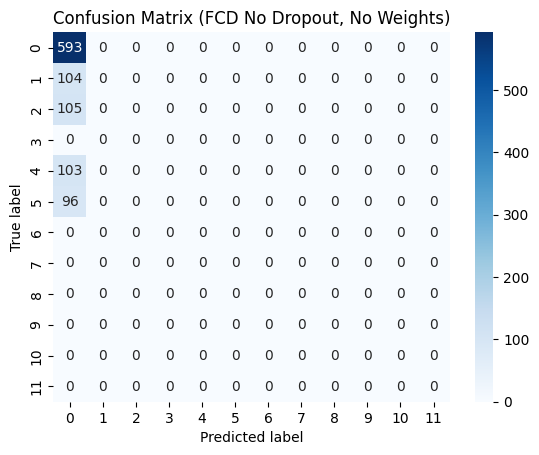

Accuracy: 0.5924075924075924
Balanced accuracy: 0.2
Macro F1: 0.14880803011292348
Weighted F1: 0.4407750342505675

Classification report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74       593
           1       0.00      0.00      0.00       104
           2       0.00      0.00      0.00       105
           4       0.00      0.00      0.00       103
           5       0.00      0.00      0.00        96

    accuracy                           0.59      1001
   macro avg       0.12      0.20      0.15      1001
weighted avg       0.35      0.59      0.44      1001


=== FCD without Dropout, with class weights ===
Epoch  1 | Val Accuracy: 98.40%
Epoch  2 | Val Accuracy: 99.14%
Epoch  3 | Val Accuracy: 99.63%
Epoch  4 | Val Accuracy: 99.75%
Epoch  5 | Val Accuracy: 99.75%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 95.43%
Epoch  2 | Val Accuracy: 99.26%
Epoch  3 | Val Accuracy: 99.51%
Epoch  4 | Val Accuracy: 99.75%
Epoch  5 | Va

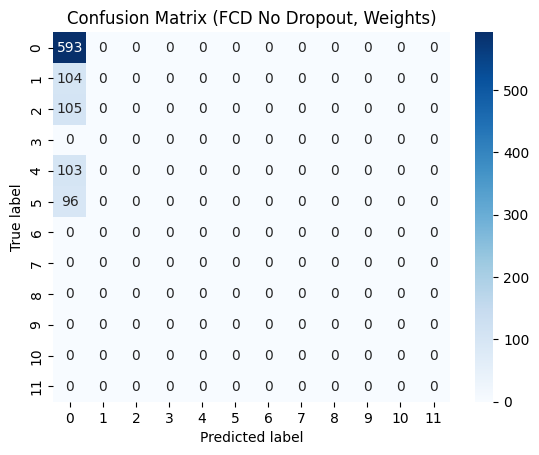

Accuracy: 0.5924075924075924
Balanced accuracy: 0.2
Macro F1: 0.14880803011292348
Weighted F1: 0.4407750342505675

Classification report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74       593
           1       0.00      0.00      0.00       104
           2       0.00      0.00      0.00       105
           4       0.00      0.00      0.00       103
           5       0.00      0.00      0.00        96

    accuracy                           0.59      1001
   macro avg       0.12      0.20      0.15      1001
weighted avg       0.35      0.59      0.44      1001


=== FCD with Dropout, without class weights ===
Epoch  1 | Val Accuracy: 99.01%
Epoch  2 | Val Accuracy: 99.26%
Epoch  3 | Val Accuracy: 99.26%
Epoch  4 | Val Accuracy: 99.51%
Epoch  5 | Val Accuracy: 99.51%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 98.27%
Epoch  2 | Val Accuracy: 98.77%
Epoch  3 | Val Accuracy: 99.01%
Epoch  4 | Val Accuracy: 99.14%
Epoch  5 | Va

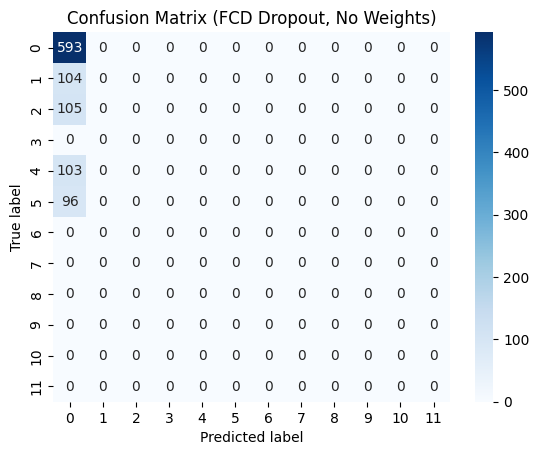

Accuracy: 0.5924075924075924
Balanced accuracy: 0.2
Macro F1: 0.14880803011292348
Weighted F1: 0.4407750342505675

Classification report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74       593
           1       0.00      0.00      0.00       104
           2       0.00      0.00      0.00       105
           4       0.00      0.00      0.00       103
           5       0.00      0.00      0.00        96

    accuracy                           0.59      1001
   macro avg       0.12      0.20      0.15      1001
weighted avg       0.35      0.59      0.44      1001


=== FCD with Dropout, with class weights ===
Epoch  1 | Val Accuracy: 96.42%
Epoch  2 | Val Accuracy: 98.52%
Epoch  3 | Val Accuracy: 99.14%
Epoch  4 | Val Accuracy: 99.26%
Epoch  5 | Val Accuracy: 99.63%
Test Accuracy: 59.24%
Epoch  1 | Val Accuracy: 92.47%
Epoch  2 | Val Accuracy: 97.28%
Epoch  3 | Val Accuracy: 97.16%
Epoch  4 | Val Accuracy: 99.01%
Epoch  5 | Val A

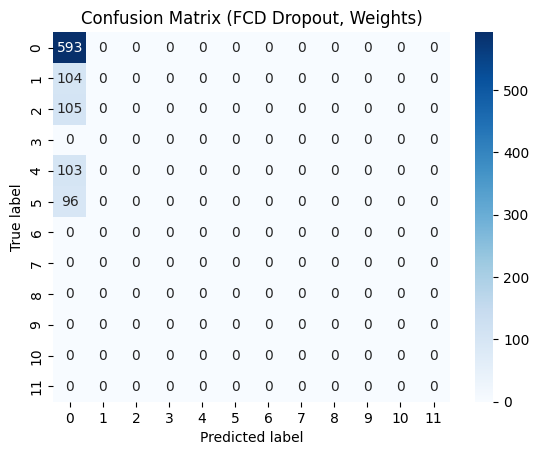

Accuracy: 0.5924075924075924
Balanced accuracy: 0.2
Macro F1: 0.14880803011292348
Weighted F1: 0.4407750342505675

Classification report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74       593
           1       0.00      0.00      0.00       104
           2       0.00      0.00      0.00       105
           4       0.00      0.00      0.00       103
           5       0.00      0.00      0.00        96

    accuracy                           0.59      1001
   macro avg       0.12      0.20      0.15      1001
weighted avg       0.35      0.59      0.44      1001



In [ ]:
# --- Hyperparameter search  ---
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
dropout_ps = [0.0, 0.3]  
epochs = 5
num_classes = int(np.max(y_train)) + 1

# Compute class weights to handle class imbalance
class_counts = np.bincount(y_train)
weights = 1. / class_counts
weights = torch.tensor(weights, dtype=torch.float32).to(device)

results = []

# Try all combinations of dropout and class weights
for use_dropout in [False, True]:
    for use_weights in [False, True]:
        best_acc = 0
        best_model = None
        best_params = {}
        print(f"\n=== FCD {'with' if use_dropout else 'without'} Dropout, {'with' if use_weights else 'without'} class weights ===")
        for lr in learning_rates:
            for batch_size in batch_sizes:
                for dropout_p in ([0.0] if not use_dropout else [0.3, 0.5]):
                    # Prepare data loaders for current configuration
                    train_loader, val_loader, input_dim = prepare_data_all_features(X_ext_train, y_train, batch_size=batch_size)
                    test_loader = prepare_test_all_features(X_ext_test, y_test, batch_size=batch_size)
                    class_w = weights if use_weights else None
                    
                    # Train the model
                    model = train_fcd(
                        train_loader, val_loader, input_dim, num_classes,
                        epochs=epochs, lr=lr, dropout_p=dropout_p, class_weights=class_w
                    )

                    # Evaluate on test set
                    acc = test_fcd(model, test_loader)
                    results.append({
                        'dropout': dropout_p,
                        'weights': use_weights,
                        'lr': lr,
                        'batch_size': batch_size,
                        'test_acc': acc
                    })

                    # Save best model for this configuration
                    if acc > best_acc:
                        best_acc = acc
                        best_model = copy.deepcopy(model)
                        best_params = {
                            'dropout': dropout_p,
                            'weights': use_weights,
                            'lr': lr,
                            'batch_size': batch_size
                        }
        print(f"Best: {best_params}, test_acc={best_acc:.3f}")

        # --- Evaluate best model on test set and show confusion matrix ---
        y_true = []
        y_pred = []
        best_model.eval()
        test_loader = prepare_test_all_features(X_ext_test, y_test, batch_size=best_params['batch_size'])
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = best_model(xb)
                preds = outputs.argmax(dim=1)
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        all_labels = np.arange(0, num_classes)
        cm = confusion_matrix(y_true, y_pred, labels=all_labels)  # Sense normalize
        plt.figure(figsize=(8*0.8,6*0.8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.title(f"Confusion Matrix (FCD {'Dropout' if use_dropout else 'No Dropout'}, {'Weights' if use_weights else 'No Weights'})")
        plt.show()

        labels_test = np.unique(y_true)
        
        # Print evaluation metrics for the best model
        print("Accuracy:", accuracy_score(y_true, y_pred))
        print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
        print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
        print("Weighted F1:", f1_score(y_true, y_pred, average='weighted'))
        print("\nClassification report:\n", classification_report(y_true, y_pred, labels=labels_test, zero_division=0))
        

# Collect all results in a DataFrame
df_results = pd.DataFrame(results)

## Summary

In [33]:
# --- Collect and display the best results for each model configuration ---
summary_fcd = []
for use_dropout in [False, True]:
    for use_weights in [False, True]:
        sub = df_results[(df_results['dropout'].isin([0.0] if not use_dropout else [0.3, 0.5])) & (df_results['weights'] == use_weights)]
        if len(sub) == 0:
            continue
        idx_best = sub['test_acc'].idxmax()
        row = sub.loc[idx_best]
        summary_fcd.append({
            "Model": f"FCD ({'Dropout' if use_dropout else 'No Dropout'}, {'Weights' if use_weights else 'No Weights'})",
            "Dropout": "Yes" if use_dropout else "No",
            "Class Weights": "Yes" if use_weights else "No",
            "Best Accuracy": f"{row['test_acc']*100:.2f}%",
            "Learning Rate": row['lr'],
            "Batch Size": row['batch_size'],
            "Dropout p": row['dropout'] if use_dropout else "-"
        })

df_summary_fcd = pd.DataFrame(summary_fcd)
print(df_summary_fcd.to_markdown(index=False))

| Model                        | Dropout   | Class Weights   | Best Accuracy   |   Learning Rate |   Batch Size | Dropout p   |
|:-----------------------------|:----------|:----------------|:----------------|----------------:|-------------:|:------------|
| FCD (No Dropout, No Weights) | No        | No              | 59.24%          |           0.001 |           32 | -           |
| FCD (No Dropout, Weights)    | No        | Yes             | 59.24%          |           0.001 |           32 | -           |
| FCD (Dropout, No Weights)    | Yes       | No              | 59.24%          |           0.001 |           32 | 0.3         |
| FCD (Dropout, Weights)       | Yes       | Yes             | 59.24%          |           0.001 |           32 | 0.3         |
